# Model Evaluation Analysis

This notebook analyzes model evaluation results by comparing:
1. **Base Model Performance** - CER and WER across all base models
2. **Model Size vs Accuracy** - Relationship between model size and accuracy
3. **Base vs Fine-Tuned** - Comparison of base models with their fine-tuned counterparts
4. **Base vs LLM-Corrected** - Comparison of base models with LLM-corrected versions

Run `test_all.sh` to generate the evaluation metrics for all models first.

In [ ]:
!bash test_all.sh

## Fine-Tune Models

Run the `finetune.py` script to fine-tune specific models on the `data/IEHHR` dataset.

In [ ]:
# Example: Fine-tune Qwen2.5-VL-7B-Instruct on data/IEHHR
!python finetune.py \
    --model "Qwen/Qwen2.5-VL-7B-Instruct" \
    --annotation_file "data/IEHHR/train_annotations.jsonl" \
    --base_image_dir "data/IEHHR/" \
    --output_dir "./checkpoints/qwen2.5-7B-iehhr" \
    --epochs 3 \
    --batch_size 2 \
    --grad_accum_steps 8 \
    --learning_rate 2e-4

In [ ]:
# Example: Fine-tune Qwen3-VL-2B-Instruct on data/IEHHR
!python finetune.py \
    --model "Qwen/Qwen3-VL-2B-Instruct" \
    --annotation_file "data/IEHHR/train_annotations.jsonl" \
    --base_image_dir "data/IEHHR/" \
    --output_dir "./checkpoints/qwen3-2B-iehhr" \
    --epochs 3 \
    --batch_size 2 \
    --grad_accum_steps 8 \
    --learning_rate 2e-4

## Generate LLM-Corrected Outputs

Use the LLMCorrector to post-process OCR outputs and improve transcription quality.

In [ ]:
from llm_corrector import LLMCorrector
from infer import load_model, transcribe_image
from pathlib import Path
import json

# Initialize LLM corrector (default: Qwen2.5-7B-Instruct)
corrector = LLMCorrector(model_id="Qwen/Qwen2.5-7B-Instruct")

# Load VLM model for OCR
model = load_model("Qwen/Qwen3-VL-2B-Instruct")

# Example: Transcribe and correct a single image
image_path = Path("data/IEHHR/Volum_069_Registres_0004.jpg")

# Get raw transcription
raw_transcription = transcribe_image(model, image_path)
print("Raw transcription:")
print(raw_transcription)

# Apply LLM correction
corrected_transcription = corrector.correct(raw_transcription)
print("\nCorrected transcription:")
print(corrected_transcription)

In [ ]:
# Example: Process all outputs in a directory with LLM correction
import os

def correct_outputs_with_llm(
    input_json_path: str,
    output_json_path: str,
    model_id: str = "Qwen/Qwen2.5-7B-Instruct"
):
    """
    Load VLM outputs and apply LLM correction to improve transcription quality.
    
    Args:
        input_json_path: Path to the JSON file with VLM outputs
        output_json_path: Path to save the LLM-corrected results
        model_id: LLM model to use for correction
    """
    from llm_corrector import LLMCorrector
    
    # Load input data
    with open(input_json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Initialize LLM corrector
    corrector = LLMCorrector(model_id=model_id)
    
    # Process results
    corrected_results = []
    for item in data.get('results_details', []):
        raw_pred = item.get('predicted_text', '')
        corrected_pred = corrector.correct(raw_pred)
        corrected_item = item.copy()
        corrected_item['predicted_text'] = corrected_pred
        corrected_results.append(corrected_item)
        print(f"Corrected: {item.get('image_path', 'unknown')}")
    
    # Save corrected results
    corrected_data = data.copy()
    corrected_data['results_details'] = corrected_results
    corrected_data['model_id'] = data.get('model_id', 'unknown') + '_llm-correction'
    
    with open(output_json_path, 'w', encoding='utf-8') as f:
        json.dump(corrected_data, f, indent=4, ensure_ascii=False)
    
    print(f"\nCorrected results saved to: {output_json_path}")

# Example usage:
# correct_outputs_with_llm(
#     input_json_path='outputs/eval_Qwen_Qwen3-VL-2B-Instruct.json',
#     output_json_path='outputs/eval_Qwen_Qwen3-VL-2B-Instruct_llm-correction.json'
# )

## Import Plotting Utilities

In [1]:
from plot_utils import (
    load_base_model_results,
    load_finetuned_comparison_data,
    load_llm_correction_comparison_data,
    plot_cer_wer_comparison,
    plot_model_size_vs_accuracy,
    plot_base_vs_finetuned,
    plot_llm_correction_comparison,
    run_all_plots
)

## 1. Compare Accuracies

Plot the Character Error Rate (CER) and Word Error Rate (WER) across all base models.

In [2]:
# Load base model results
df_base = load_base_model_results('outputs')
df_base

,Model,Dataset,CER,WER
0,Qwen/Qwen3-VL-30B-A3B-Instruct,data_alltest,0.124492,0.355625
1,Qwen/Qwen2.5-VL-7B-Instruct,data_alltest,0.125798,0.411487
2,Qwen/Qwen3-VL-8B-Instruct,data_alltest,0.128555,0.375295
3,Qwen/Qwen2-VL-7B-Instruct,data_alltest,0.136970,0.413847
4,Qwen/Qwen2.5-VL-3B-Instruct,data_alltest,0.174550,0.459481
5,Qwen/Qwen2.5-VL-32B-Instruct,data_alltest,0.535403,0.815106
6,Qwen/Qwen2-VL-2B-Instruct,data_alltest,0.632182,0.881196
7,Qwen/Qwen3-VL-2B-Instruct,data_alltest,0.828787,1.800157


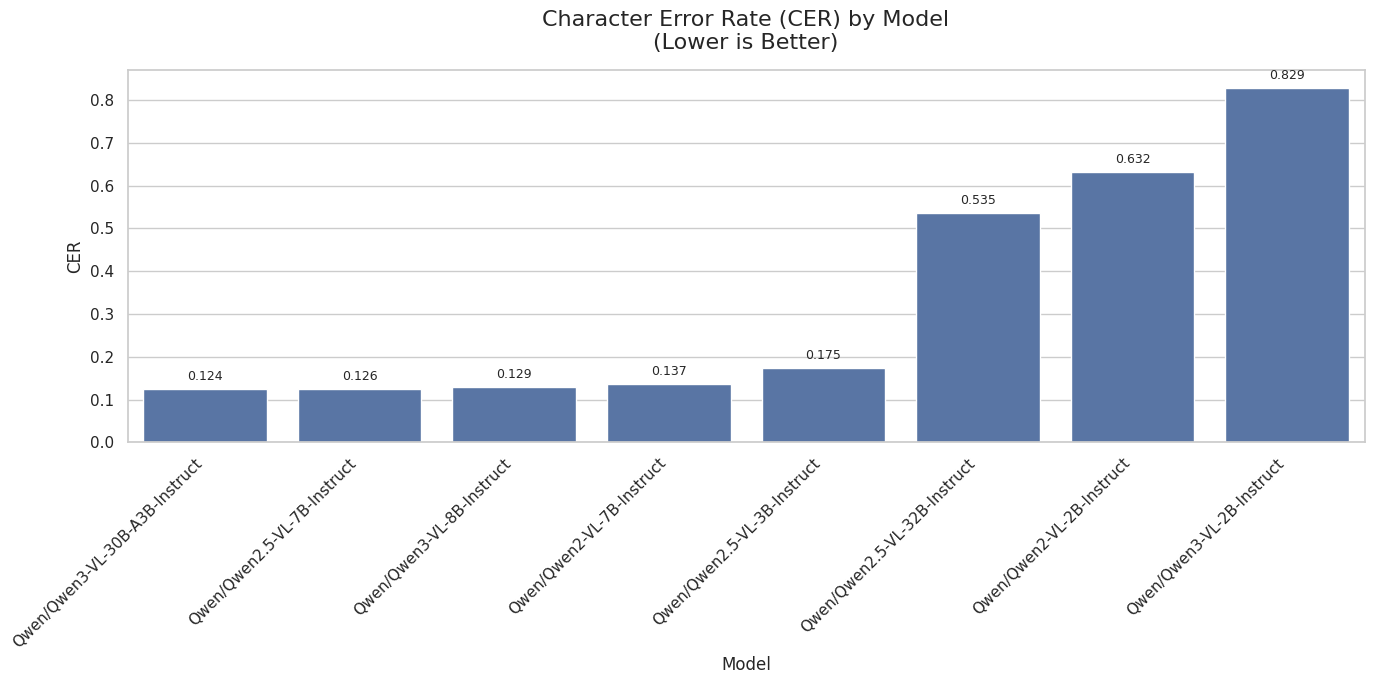

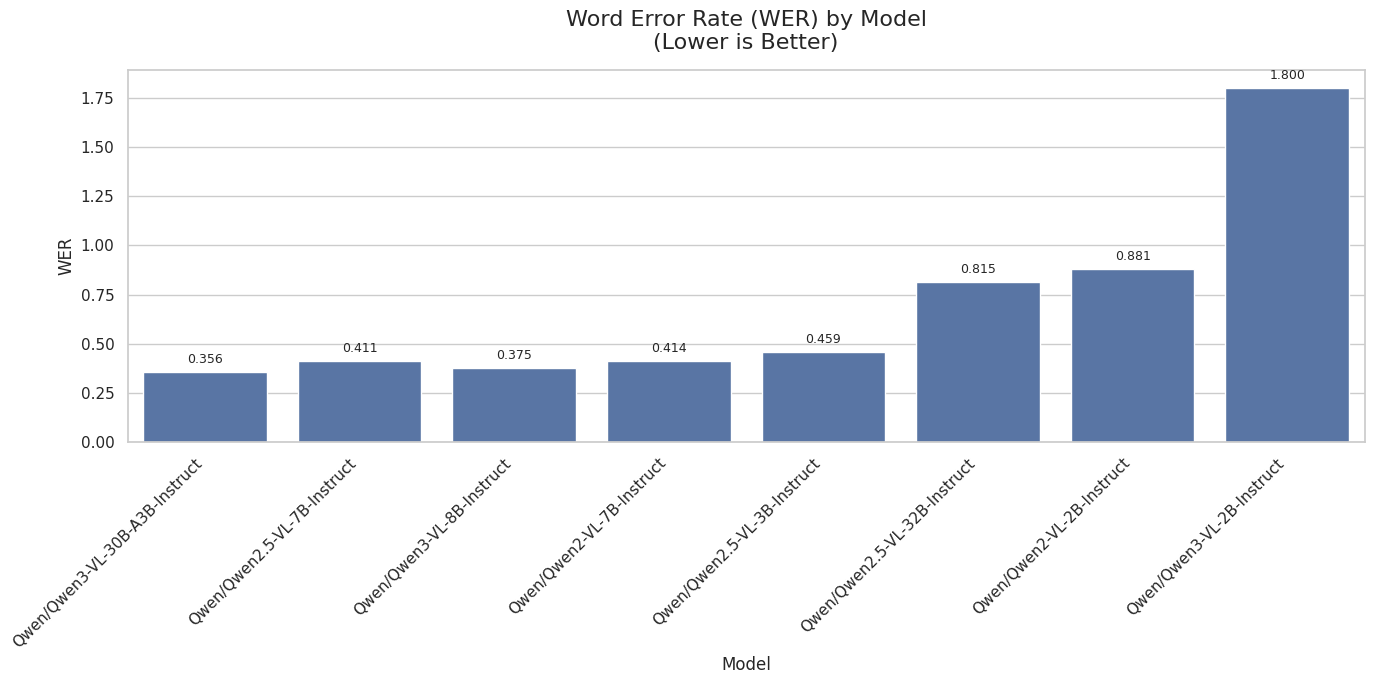

In [3]:
# Plot CER and WER comparison
plot_cer_wer_comparison(df_base)

## 2. Accuracy vs Model Size

Plot the relationship between model size (in billions of parameters) and accuracy (1 - CER).

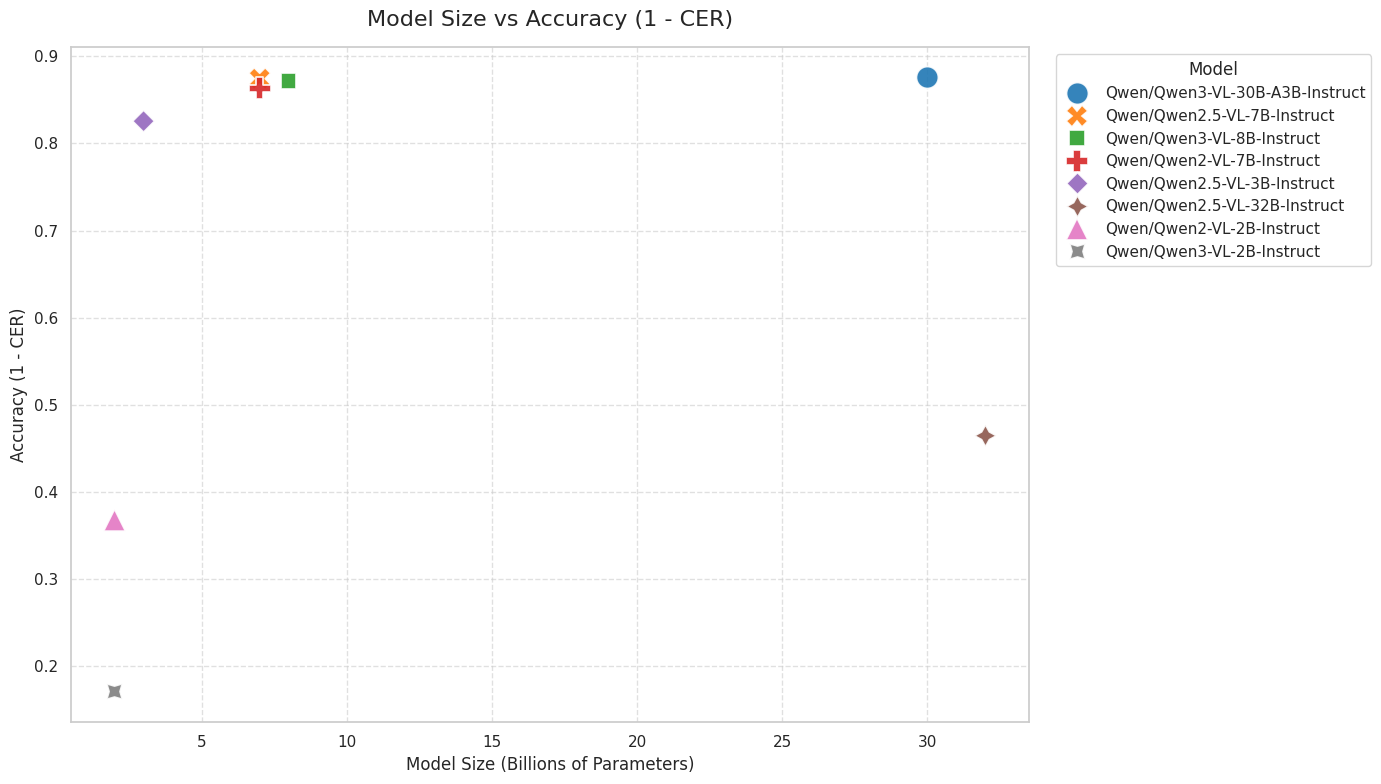

In [4]:
# Plot model size vs accuracy
plot_model_size_vs_accuracy(df_base)

## 3. Compare Base vs Fine-Tuned Models

Plot the Character Error Rate (CER) and Word Error Rate (WER) comparing base models with their fine-tuned counterparts.

In [5]:
# Load and plot base vs fine-tuned comparison
df_finetuned = load_finetuned_comparison_data('outputs', 'finetuned_outputs')
df_finetuned

,Model,Type,CER,WER
0,Qwen/Qwen2.5-VL-7B-Instruct,Base,0.125798,0.411487
1,Qwen/Qwen2.5-VL-7B-Instruct,Base,0.132327,0.412274
2,Qwen/Qwen2.5-VL-7B-Instruct,Fine-Tuned,0.130441,0.420928
3,Qwen/Qwen3-VL-2B-Instruct,Base,1.285694,2.280094
4,Qwen/Qwen3-VL-2B-Instruct,Base,0.828787,1.800157
5,Qwen/Qwen3-VL-2B-Instruct,Fine-Tuned,0.401335,1.151062


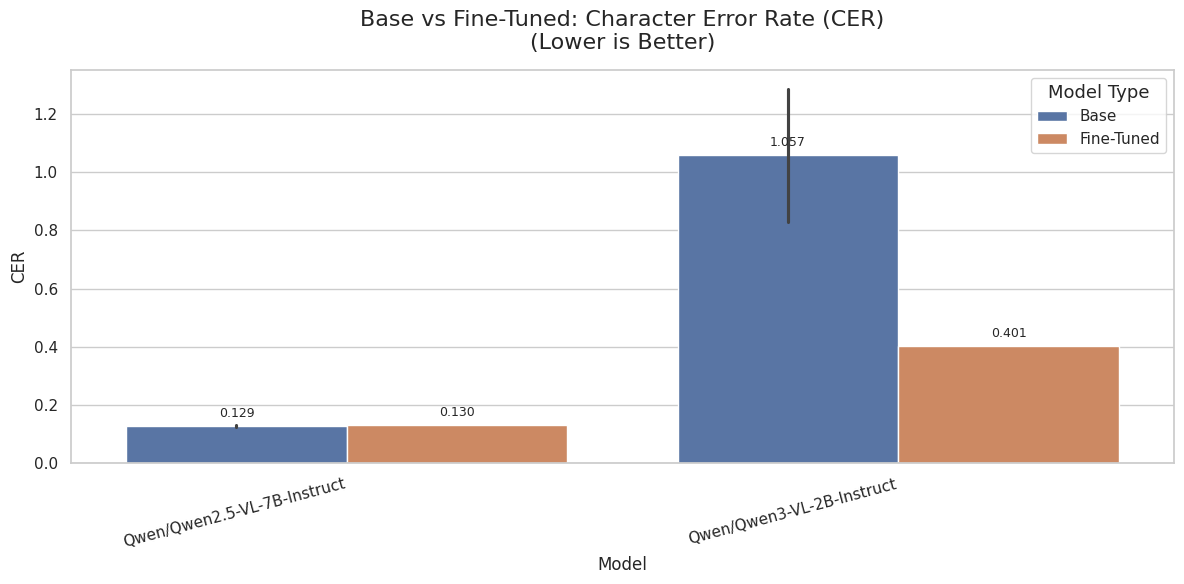

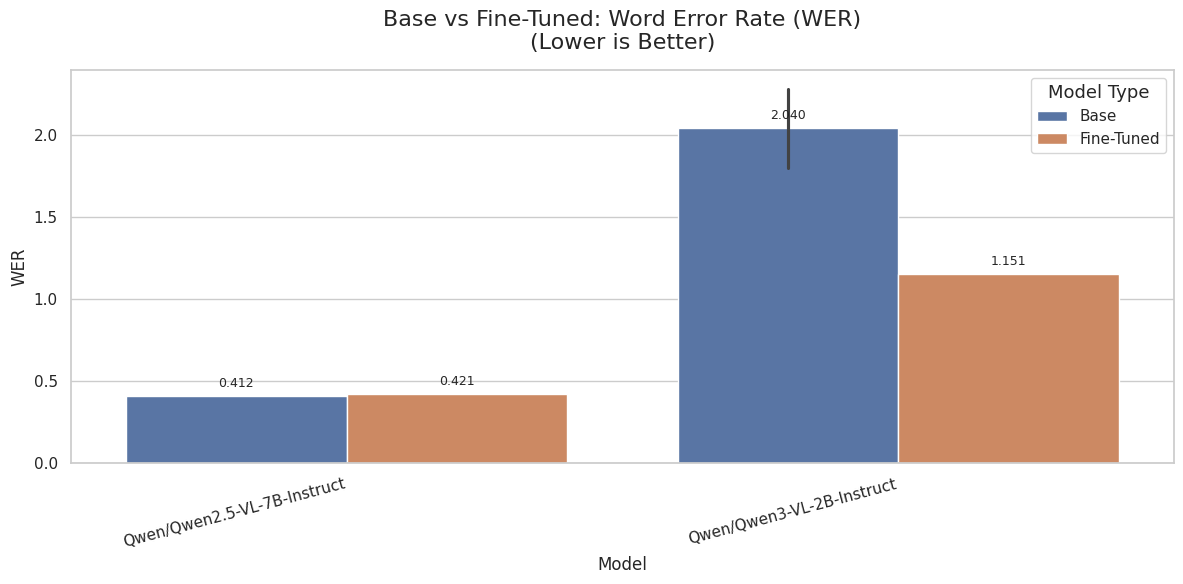

In [6]:
# Plot comparison
plot_base_vs_finetuned(df_finetuned)

## 4. Compare Models With and Without LLM Correction

Plot the Character Error Rate (CER) and Word Error Rate (WER) comparing base VLM models with their LLM-corrected counterparts.

In [7]:
# Load and plot base vs LLM-corrected comparison
df_llm = load_llm_correction_comparison_data('outputs')
df_llm

,Model,Type,CER,WER
0,Qwen/Qwen2.5-VL-7B-Instruct,Base,0.125798,0.411487
1,Qwen/Qwen2.5-VL-7B-Instruct,LLM-Corrected,0.132327,0.412274
2,Qwen/Qwen3-VL-2B-Instruct,Base,0.828787,1.800157
3,Qwen/Qwen3-VL-2B-Instruct,LLM-Corrected,1.285694,2.280094


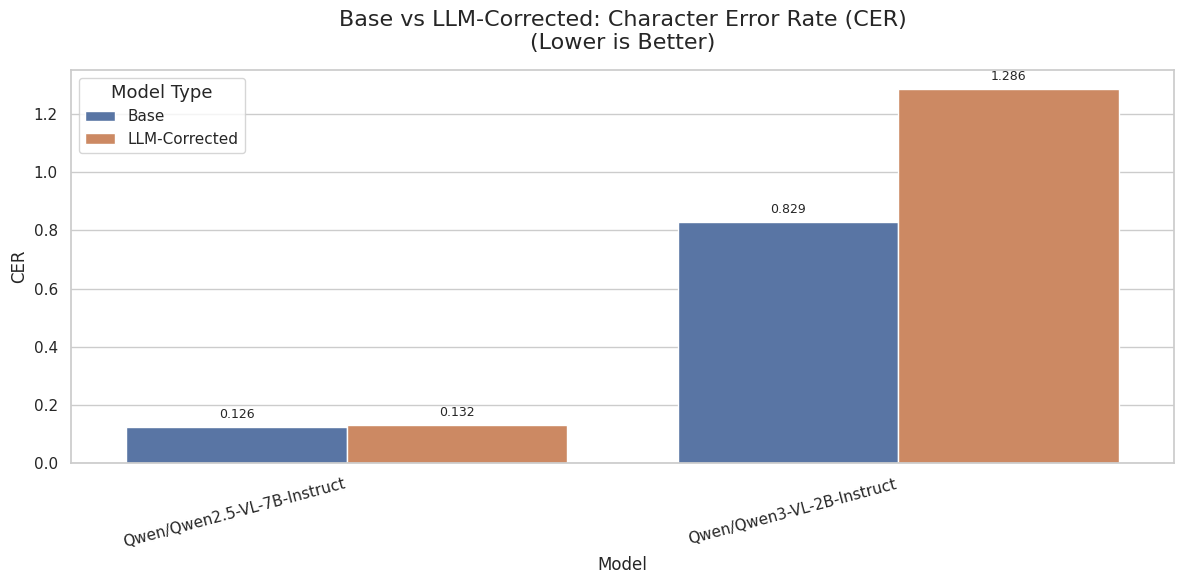

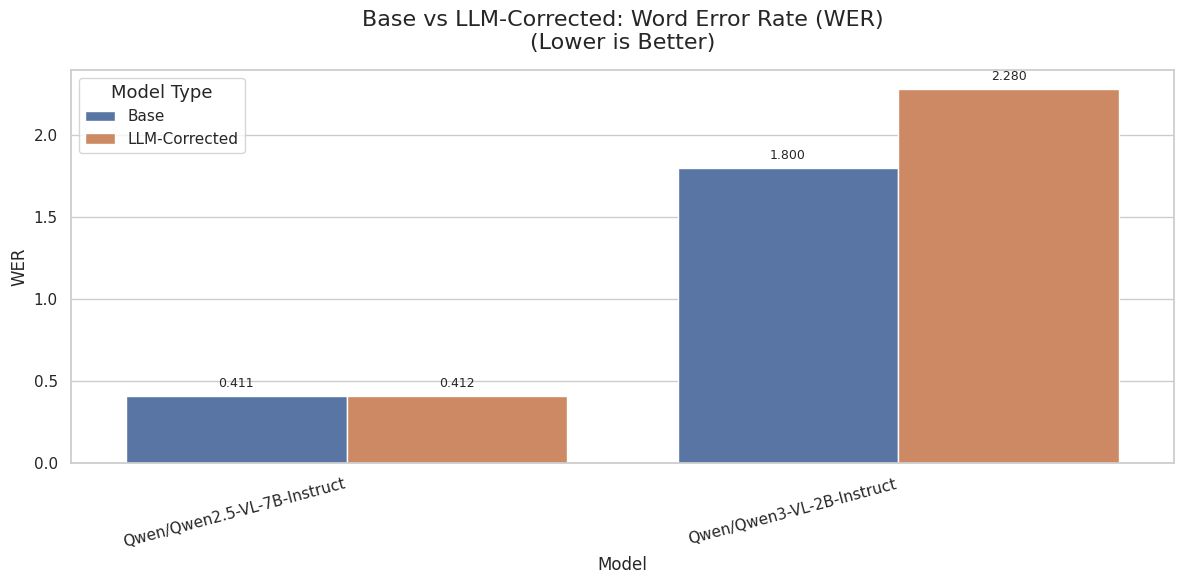

In [8]:
# Plot comparison
plot_llm_correction_comparison(df_llm)

## Run All Plots

Alternatively, run all plots at once using the `run_all_plots()` function.

In [ ]:
# Run all plots
run_all_plots('outputs', 'finetuned_outputs')

# RenAIssance GSoC 2026 Evaluation Report
### Test II: Handwritten Text Recognition via VLM Pipeline

**Author:** Tushar Tyagi  
**Project:** RenAIssance: AI-assisted transcription of historical manuscripts  
**Submission:** GSoC 2026 Applicant Evaluation

---

## Table of Contents

1. [Introduction & Motivation](#1-introduction--motivation)
2. [Dataset Description](#2-dataset-description)
3. [Methodology](#3-methodology)
4. [Results & Analysis](#4-results--analysis)
5. [Conclusions & Future Work](#5-conclusions--future-work)

---

## 1. Introduction & Motivation

The digitisation of historical handwritten manuscripts is a foundational challenge for the digital humanities. Documents such as early modern notarial records, marriage registers, and ecclesiastical sources encode irreplaceable knowledge about demographics, language, and society, yet remain largely inaccessible due to the difficulty of automated transcription. Traditional OCR systems were designed for printed, typeface-consistent text and degrade sharply when confronted with cursive historical scripts, archaic letterforms, ligatures, and irregular spacing.

This work was completed as part of the **RenAIssance GSoC 2026 Test II**, which calls for building an OCR pipeline grounded in a Large Language Model (LLM) or Vision-Language Model (VLM), where the model is not merely a post-processing corrector but participates throughout the recognition process, which are reading the image, interpreting ambiguous characters, and producing a faithful transcription.

The central research questions driving this work were:

- Which openly available VLMs have the strongest zero-shot capability for historical handwritten text recognition (HTR)?
- Does model size correlate with transcription accuracy?
- Can parameter-efficient fine-tuning (LoRA) meaningfully improve accuracy, and does it help weaker models more than stronger ones?
- Can a large LLM applied as a post-processing correction layer further reduce transcription errors?

---

## 2. Dataset Description

### 2.1 Primary Evaluation Dataset: RenAIssance Handwritten Sources

The primary dataset used for all model evaluation consists of the **RenAIssance-provided scanned handwritten sources**, a curated collection of historical manuscript images paired with expert ground-truth transcriptions. The documents represent early modern handwritten records whose transcriptions serve as gold-standard references during evaluation. Marginalia were disregarded; only the main body text was considered.

### 2.2 Fine-Tuning Dataset IEHHR (Esposalles)

Fine-tuning experiments used the **IEHHR dataset** (Information Extraction in Historical Handwritten Records), specifically the **Esposalles database**, which consists of 125 pages of a marriage licence book conserved at the Archives of the Cathedral of Barcelona. The corpus is written in old Catalan by a single writer from the 17th century. Each record contains named entities such as names, occupations, places of origin, and marital statuses. The dataset is provided in **PAGE XML format**, which encodes both the image and word-level transcription ground truth.

A custom preprocessing script (`prepare_xml_dataset.py`) was written to parse the PAGE XML files, extract word-level transcriptions, and convert them into the JSONL annotation format required by the fine-tuning pipeline.

### 2.3 Evaluation Metrics

Two standard metrics from the speech and OCR community were used, computed using the `jiwer` library:

- **Character Error Rate (CER)**: The edit distance between predicted and ground-truth text at the character level, normalised by the length of the ground truth. Lower is better; a perfect transcription yields CER = 0.
- **Word Error Rate (WER)**: The same edit distance computed at the word level. WER is generally higher than CER and more sensitive to word boundary and spacing errors.

Both metrics were computed **after text normalisation** to avoid penalising the model for historically valid spelling differences. The normalisation pipeline (order-sensitive) applied the following transformations to both prediction and ground truth before scoring:

1. **Accent removal** strips diacritics while preserving `ñ` / `Ñ`
2. **Cedilla replacement** `ç` / `Ç` → `z` / `Z`
3. **Macron/tilde expansion** expands shorthand marks (e.g., `q̃` → `que`, `ā` → `an`)
4. **u/v and f/s disambiguation** dictionary-driven substitution for historically interchangeable characters using `pyspellchecker` with a Spanish lexicon
5. **Lower-casing** final standardisation before metric computation

---

## 3. Methodology

### 3.1 Overview

The pipeline was implemented in a modular Python codebase with the following components:

| Module | Role |
|---|---|
| `main.py` | CLI orchestrator; runs the full evaluation pipeline |
| `data_loader.py` | Loads matched image–transcription pairs from the test directory |
| `normalize.py` | Paleographic text normalisation before metric computation |
| `infer.py` / `vlm_models/` | 4-bit NF4 quantised VLM loading and zero-shot inference |
| `evaluate.py` | CER and WER calculation via `jiwer` |
| `finetune.py` | LoRA fine-tuning of VLMs on custom JSONL datasets |
| `prepare_xml_dataset.py` | PAGE XML → JSONL conversion for fine-tuning |

### 3.2 Model Selection

All experiments used models from the **Qwen VL family** (Qwen2-VL, Qwen2.5-VL, Qwen3-VL). This family was chosen for three reasons:

- **Open source and locally runnable**: no API dependencies; all inference runs on local GPU hardware
- **Range of sizes**: models span from 2B to 32B parameters, enabling a scaling analysis
- **LoRA fine-tuning support**: the architecture is well-supported by `transformers` and `peft`, making supervised fine-tuning straightforward

Eight models were evaluated in the base zero-shot benchmark:

| Model | Size |
|---|---|
| Qwen/Qwen3-VL-30B-A3B-Instruct | ~30B (MoE) |
| Qwen/Qwen2.5-VL-7B-Instruct | 7B |
| Qwen/Qwen3-VL-8B-Instruct | 8B |
| Qwen/Qwen2-VL-7B-Instruct | 7B |
| Qwen/Qwen2.5-VL-3B-Instruct | 3B |
| Qwen/Qwen2.5-VL-32B-Instruct | 32B |
| Qwen/Qwen2-VL-2B-Instruct | 2B |
| Qwen/Qwen3-VL-2B-Instruct | 2B |

All models were loaded with **4-bit NF4 quantisation** to make inference feasible within consumer GPU memory constraints. Evaluation results were cached to JSON, allowing subsequent LLM-correction experiments to reuse existing VLM predictions without re-running inference.

### 3.3 Zero-Shot Inference Prompt

The following prompt was used for all base model evaluations:

```
Transcribe the handwritten text in this image exactly as written.
Do not correct spelling, punctuation, or grammar.
Preserve all original characters.
```

This instruction was deliberately minimal and non-interventionist, directing the model to act as a faithful transcriber rather than a language interpreter.

### 3.4 Fine-Tuning with LoRA

Two models were selected for fine-tuning on the IEHHR dataset:

- **Qwen/Qwen2.5-VL-7B-Instruct**: the best-performing base model (CER 0.124)
- **Qwen/Qwen3-VL-2B-Instruct**: the worst-performing base model (CER 0.829)

The goal was to assess both the ceiling that fine-tuning can push a strong model to, and the degree to which fine-tuning can close the gap for a weaker model.

Fine-tuning used **LoRA (Low-Rank Adaptation)** targeting the attention projection matrices (`q_proj`, `v_proj`, `k_proj`, `o_proj`) with the following hyperparameters:

| Hyperparameter | Value |
|---|---|
| Epochs | 3 |
| Batch size | 2 |
| Gradient accumulation steps | 8 |
| Effective batch size | 16 |
| Learning rate | 2e-4 |
| LoRA rank (`r`) | 16 |
| LoRA alpha | 32 |
| LoRA dropout | 0.05 |
| Precision | bfloat16 |
| Optimizer | Paged AdamW |

To improve generalisation, the fine-tuning pipeline randomly sampled from a **directory of diverse prompts** at each training step. The prompts used included:

- *"Transcribe the handwritten text in this image exactly as written. Do not correct spelling, punctuation, or grammar. Preserve all original characters."*
- *"Please transcribe the text from the provided image of a historical document... Do not attempt to modernise the language or fix perceived errors."*
- *"What text do you see in this handwritten document? Please write down everything you can read, maintaining the original spelling and formatting."*
- *"OCR Task: Extract and transcribe all visible text from this document image. Preserve every word, character, punctuation mark, and abbreviation exactly as they appear."*
- *"You are analyzing a historical document. Read the handwritten or printed text in the image and provide a faithful transcription..."*
- *"Convert this handwritten text into digital form. Transcribe exactly what is written, character by character..."*
- *"Transcribe this document precisely. Maintain original spelling, case, punctuation, and formatting."*

This prompt diversity strategy prevents the model from overfitting to a single instruction phrasing and encourages robust instruction-following behaviour.

### 3.5 LLM Correction Layer

As an additional experiment, **Qwen/Qwen2.5-72B-Instruct** was applied as a post-processing correction layer on the raw VLM transcription output. This stage was applied to two models: Qwen2.5-VL-7B-Instruct and Qwen3-VL-2B-Instruct.

The corrector was prompted as follows:

```
You are an expert paleographer and linguist specializing in historical Spanish manuscripts.
Your task is to correct OCR errors from a transcription model. Fix obvious spelling mistakes,
character hallucinations, and formatting errors.

CRITICAL INSTRUCTIONS:
1. Preserve the original historical language, including archaic spellings (e.g., 'ç', 'x' for 'j'),
   abbreviations, and missing accents.
2. Do NOT modernize the language.
3. Output ONLY the corrected text. Do NOT include any preamble or explanations.
```

The corrector was intentionally instructed to respect historical linguistic conventions, avoiding the risk of modernising archaic forms that are valid in context.

---

## 4. Results & Analysis

### 4.1 Base Model Comparison

The table below summarises the zero-shot performance of all eight evaluated models on the RenAIssance handwritten test set:

| Rank | Model | CER ↓ | WER ↓ |
|---|---|---|---|
| 1 | Qwen/Qwen3-VL-30B-A3B-Instruct | **0.124** | **0.356** |
| 2 | Qwen/Qwen2.5-VL-7B-Instruct | 0.126 | 0.411 |
| 3 | Qwen/Qwen3-VL-8B-Instruct | 0.129 | 0.375 |
| 4 | Qwen/Qwen2-VL-7B-Instruct | 0.137 | 0.414 |
| 5 | Qwen/Qwen2.5-VL-3B-Instruct | 0.175 | 0.459 |
| 6 | Qwen/Qwen2.5-VL-32B-Instruct | 0.535 | 0.815 |
| 7 | Qwen/Qwen2-VL-2B-Instruct | 0.632 | 0.881 |
| 8 | Qwen/Qwen3-VL-2B-Instruct | 0.829 | 1.800 |

**Key observations:**

- The **top four models are remarkably close** in CER (0.124–0.175), suggesting a performance plateau for capable VLMs on this task at zero-shot inference.
- **Qwen3-VL-30B-A3B** achieves the best CER (0.124), but **Qwen2.5-VL-7B** comes extremely close (0.126) at a fraction of the parameter count, which is a compelling efficiency trade-off.
- **Qwen2.5-VL-32B performs unexpectedly poorly** (CER 0.535), significantly worse than the 7B variant of the same generation. This is likely an artefact of quantisation at this scale, or instruction-following degradation at the 32B size under 4-bit compression.
- **Qwen3-VL-2B** is the weakest model overall (CER 0.829, WER 1.800), with WER exceeding 1.0, indicating that on average, more than one word per reference word is incorrectly transcribed.
- There is **no simple linear relationship between model size and accuracy**. The scatter plot of model size vs. accuracy (1 - CER) confirms this: both very small and very large models underperform mid-range models, pointing to the importance of model architecture and training quality over raw parameter count.

### 4.2 Fine-Tuning Results

After 3 epochs of LoRA fine-tuning on the IEHHR Esposalles dataset:

| Model | Base CER | Fine-Tuned CER | Δ CER | Base WER | Fine-Tuned WER | Δ WER |
|---|---|---|---|---|---|---|
| Qwen2.5-VL-7B-Instruct | 0.129 | 0.130 | +0.001 | 0.412 | 0.421 | +0.009 |
| Qwen3-VL-2B-Instruct | 0.829 | 0.401 | **−0.428** | 1.800 | 1.151 | **−0.649** |

**Key observations:**

- Fine-tuning delivered **dramatically different outcomes** for the two models.
- For **Qwen3-VL-2B**, fine-tuning reduced CER from 0.829 to 0.401, a **52% relative improvement**. The model went from producing near-random output to achieving meaningful transcription accuracy, demonstrating that domain-specific fine-tuning can rescue a low-capacity model.
- For **Qwen2.5-VL-7B**, fine-tuning yielded no meaningful improvement (CER 0.129 → 0.130). This is consistent with the hypothesis that a model already operating close to its capacity ceiling on the task gains little from additional supervised examples, especially when the fine-tuning corpus (Catalan notarial records) differs somewhat from the evaluation domain.
- This asymmetry confirms the intuition that **fine-tuning is most impactful for models with untapped capacity**, those that possess the visual and linguistic representations needed for the task but lack task-specific alignment.

### 4.3 LLM Correction Layer Results

Applying Qwen2.5-72B as a post-processing corrector had strikingly negative results in both cases:

| Model | Base CER | LLM-Corrected CER | Δ CER | Base WER | LLM-Corrected WER | Δ WER |
|---|---|---|---|---|---|---|
| Qwen2.5-VL-7B-Instruct | 0.126 | 0.132 | +0.006 | 0.411 | 0.412 | +0.001 |
| Qwen3-VL-2B-Instruct | 0.829 | 1.286 | **+0.457** | 1.800 | 2.280 | **+0.480** |

**Key observations:**

- The LLM correction layer **increased error rates for both models**, contrary to the intended goal.

**Qwen2.5-VL-7B per-image analysis:**

A close inspection of the per-image `vlm_prediction_raw` vs `llm_prediction_raw` fields reveals the precise failure mode for the stronger model. Across 60% images the LLM correction output is **byte-for-byte identical** to the raw VLM output, the 72B corrector made zero changes. For rest 40% images, the LLM did intervene, but its changes were **stylistic rather than substantive**: it added punctuation, expanded abbreviations, standardised capitalisation, and merged hyphenated line-breaks. None of these are OCR errors but they are formatting choices. Because the ground truth transcription preserves the raw documentary style (e.g., original abbreviations like `Dn.`, `Da.`, `Min-teguiaga`), each stylistic "improvement" introduced by the corrector diverged further from ground truth and incremented the edit distance. The CER increase of +0.006 is therefore almost entirely explained by **over-polishing**, not hallucination.

This is an important distinction: the corrector was prompted to fix OCR character errors but instead acted as a copyeditor, normalising aspects of the text that the evaluation metric correctly penalises as deviations from the source document.

**Qwen3-VL-2B failure mode:**

For the weaker model, where the VLM output was already heavily corrupted, the corrector had very little reliable signal to work from. With so many erroneous characters as input, the 72B model appears to have generated plausible-looking but incorrect historical reconstructions, effectively confabulating text rather than correcting it, which compounded the original errors and drove CER well above 1.0.

**Synthesis:**

These two failure modes suggest a general principle: LLM post-correction is sensitive to the quality of its input in fundamentally different ways depending on the error regime. When the VLM is already accurate (low CER), the corrector finds little to fix and risks introducing stylistic drift. When the VLM is inaccurate (high CER), the corrector lacks sufficient signal and hallucinates. A narrow "sweet spot" may exist in the mid-CER range where correction is genuinely beneficial, but this was not observed in the current experiments.

---

## 5. Conclusions & Future Work

### 5.1 Summary of Findings

This work evaluated a family of open-source Vision-Language Models for zero-shot historical handwritten text recognition, followed by fine-tuning and LLM-correction experiments. The main findings are:

- **Qwen2.5-VL-7B-Instruct offers the best efficiency-accuracy trade-off**, achieving near-top-tier CER (0.126) at 7B parameters, compared to the 30B model's 0.124.
- **Model size is not a reliable predictor of accuracy**: architecture generation and training quality matter more within a reasonable parameter budget.
- **LoRA fine-tuning provides substantial gains for weaker models** but offers diminishing returns for models already operating near the task ceiling.
- **Post-hoc LLM correction is counterproductive** when applied to noisy base transcriptions; it is more likely to help when the base model already achieves low CER.

### 5.2 Limitations

- All fine-tuning was performed on the **IEHHR/Esposalles dataset** (17th-century Catalan), which may not fully generalise to the RenAIssance evaluation domain. A more task-matched fine-tuning corpus would likely yield stronger improvements.
- The **4-bit NF4 quantisation** applied to all models may have disproportionately hurt larger models (e.g., Qwen2.5-VL-32B), potentially explaining their unexpected underperformance.
- Only **3 fine-tuning epochs** were used; a longer training run with early stopping might surface further improvements, particularly for the weaker model.

### 5.3 Future Directions

- **In-domain fine-tuning**: Collect and annotate a small set of RenAIssance manuscript pages and fine-tune directly on this distribution for evaluation on the same domain.
- **Interleaved LLM correction**: Rather than a post-hoc stage, explore integrating LLM linguistic reasoning as a beam-search reranking step during VLM decoding.
- **Prompt engineering for correction**: Experiment with chain-of-thought prompts that ask the corrector to reason about character-level ambiguities before producing the final text.
- **Ensemble decoding**: Combine predictions from multiple VLMs (e.g., Qwen3-VL-30B and Qwen2.5-VL-7B) via edit-distance-based consensus to reduce systematic errors.
- **Larger and diverse fine-tuning corpora**: Train on multiple historical handwriting datasets across different languages and scripts to improve generalisation.
- **Multi-turn pipeline**: Explore a pipeline where the VLM first identifies uncertain regions of text, then queries a second model for targeted re-transcription of ambiguous passages.
- **Fine-tuning the LLM corrector**: The current failure of the 72B correction layer is partly attributable to the corrector never having been trained on historical HTR correction as a dedicated task. A promising direction is to fine-tune a smaller, specialised LLM corrector using paired (noisy VLM output, ground truth) examples, so that it learns to fix OCR character errors specifically, rather than defaulting to stylistic copyediting. Training on synthetic noise augmentation of clean transcriptions could simulate the kinds of errors VLMs produce on historical scripts, making such a corrector robust across different base model quality levels and directly addressing the over-polishing failure mode observed here.
